In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

dataFolder = 'Data'
populationFile = 'uscities.xlsx'
pollutionFile = 'ctyfactbook2023.xlsx'
energyFile = 'energybycounties.xlsx'

pollutionFilePath = os.path.join(dataFolder, pollutionFile)
populationFilePath = os.path.join(dataFolder, populationFile)
energyFilePath = os.path.join(dataFolder, energyFile)

graphsFolder = 'Graphs'
scatterPlotDensity = 'scatter_plot_density.png'
scatterPlotEnergy = 'scatter_plot_energy.png'
scatterPlotEPCPPC= 'scatter_plot_EPCPPC.png'

scatterPlotDensityPath = os.path.join(graphsFolder, scatterPlotDensity)
scatterPlotEnergyPath = os.path.join(graphsFolder, scatterPlotEnergy)
scatterPlotEPCPPCPath = os.path.join(graphsFolder, scatterPlotEPCPPC)

In [2]:
# Load datasets
cities_population_df = pd.read_excel(populationFilePath)
pollution_df = pd.read_excel(pollutionFilePath)
energy_df = pd.read_excel(energyFilePath)

In [3]:
# Replace columns name
pollution_df_columns = pollution_df.iloc[1]
pollution_df = pollution_df.iloc[2:1147]
pollution_df.columns = pollution_df_columns

energy_df_columns = energy_df.iloc[3]
energy_df = energy_df.iloc[4:]
energy_df.columns = energy_df_columns

In [4]:
# Turn cities density to counties density
county_density = cities_population_df.groupby("county_fips")['density'].mean()
county_density_df = pd.DataFrame(county_density).reset_index()

In [5]:
# Change datatype of county fips
convert_dict = {"County FIPS Code":int}
pollution_df = pollution_df.astype(convert_dict)

convert_dict = {"county_fips":int}
county_density_df = county_density_df.astype(convert_dict)

# Population Scatter Plot

In [6]:
# Merge population and pollution dataset
merge_df1 = county_density_df.merge(pollution_df, how = 'inner', left_on = ['county_fips'], right_on = ['County FIPS Code']).drop(columns=['county_fips'])

In [7]:
# Choose certain columns for usage
merge_df1 = merge_df1[['density', 'County', 'PM2.5     24-hr (µg/m3) ']]

In [8]:
# Rename columns for easier access
merge_df1 = merge_df1.rename(columns={'density':'density', 'County':'county', 'PM2.5     24-hr (µg/m3) ':'pm'})

In [9]:
# Remove empty value
merge_df1 = merge_df1.query('pm != "IN" and pm != "ND"')

In [10]:
# Sort values by density
merge_df1 = merge_df1.sort_values(by=['density'])

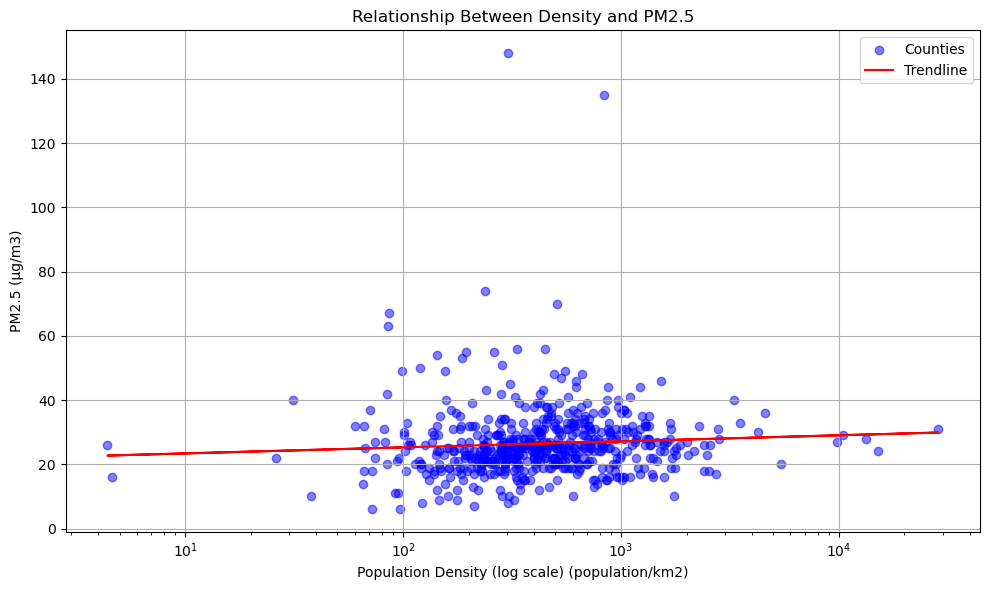

In [12]:
# Scatter plot: Density vs. pm
plt.figure(figsize=(10, 6))
plt.scatter(merge_df1['density'], merge_df1['pm'], color='blue', alpha=0.5, label='Counties')

density = np.array(merge_df1['density'])
pm = np.array(merge_df1['pm']).astype(float)

coefs = np.polyfit(np.log(density), pm, 1)
trendline = np.poly1d(coefs)
plt.plot(density, trendline(np.log(density)), color="r", label='Trendline')
plt.xscale('log')
plt.title('Relationship Between Density and PM2.5')
plt.xlabel('Population Density (log scale) (population/km2)')
plt.ylabel('PM2.5 (µg/m3)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(scatterPlotDensityPath)
plt.show()

# Energy Scatter Plot

In [13]:
# Merge energy consumption and pollution dataset
merge_df2 = energy_df.merge(pollution_df, how = 'inner', left_on = ['county_id'], right_on = ['County FIPS Code']).drop(columns=['county_id'])

In [14]:
# Choose certain columns for usage
merge_df2 = pd.concat([merge_df2.iloc[:, :13],merge_df2.iloc[:, 18], merge_df2.iloc[:,-2:-3:-1]], axis = 1)
merge_df2 = merge_df2[['consumption (TcF)', 'county_name', 'PM2.5     24-hr (µg/m3) ']]

In [15]:
# Rename columns for easier access
merge_df2 = merge_df2.rename(columns={'consumption (TcF)':'consumption', 'county_name':'county', 'PM2.5     24-hr (µg/m3) ':'pm'})

In [16]:
# Remove empty value
merge_df2 = merge_df2.query('pm != "IN" and pm != "ND"')

In [17]:
# Sort values by consumption
merge_df2 = merge_df2.sort_values(by=['consumption'])

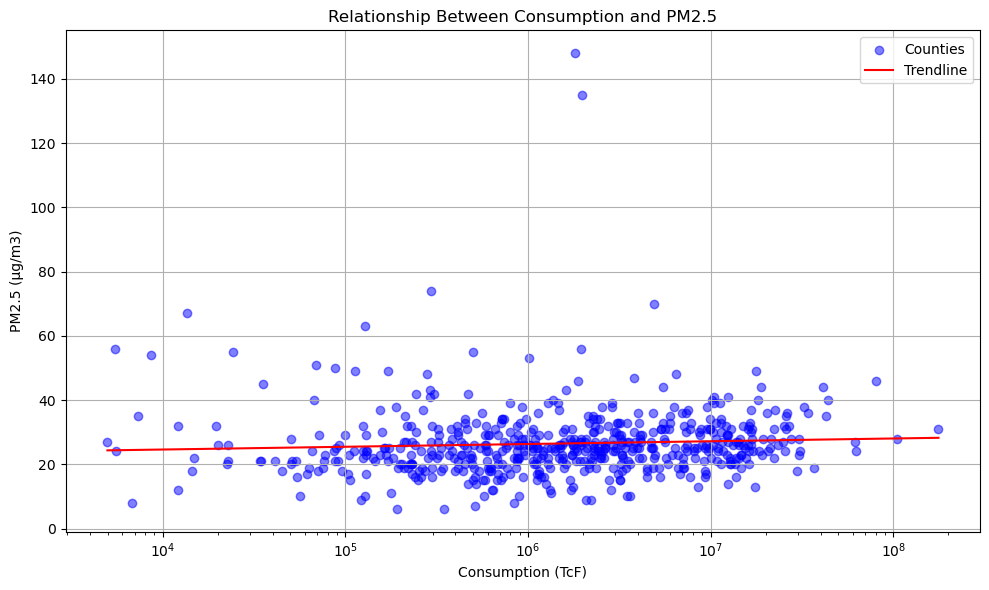

In [18]:
# Scatter plot: Consumption vs. pm
plt.figure(figsize=(10, 6))
plt.scatter(merge_df2['consumption'], merge_df2['pm'], color='blue', alpha=0.5, label='Counties')

consumption = np.array(merge_df2['consumption']).astype(float)
pm = np.array(merge_df2['pm']).astype(float)

coefs = np.polyfit(np.log(consumption), pm, 1)
trendline = np.poly1d(coefs)
plt.plot(consumption, trendline(np.log(consumption)), color="r", label='Trendline')
plt.xscale('log')
plt.title('Relationship Between Consumption and PM2.5')
plt.xlabel('Consumption (TcF)')
plt.ylabel('PM2.5 (µg/m3)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(scatterPlotEnergyPath)
plt.show()

# EPC (Energy Per Capita) Scatter Plot

In [19]:
# Define county population dataframe
county_population = cities_population_df.groupby("county_fips")['population'].sum()
county_population_df = pd.DataFrame(county_population).reset_index()

# Merge energy consumption, population and pollution dataset
merge_df3 = energy_df.merge(pollution_df, how = 'inner', left_on = ['county_id'], right_on = ['County FIPS Code']).drop(columns=['County FIPS Code', 'population'])
merge_df3 = pd.concat([merge_df3.iloc[:, :13],merge_df3.iloc[:, 18], merge_df3.iloc[:,-2:-3:-1]], axis = 1)
merge_df3 = merge_df3.merge(county_population_df, how = 'inner', left_on = ['county_id'], right_on = ['county_fips']).drop(columns=['county_fips'])

In [20]:
# Choose certain columns for usage
merge_df3 = merge_df3[['consumption (TcF)', 'county_name', 'PM2.5     24-hr (µg/m3) ', 'population']]

In [21]:
# Rename columns for easier access
merge_df3 = merge_df3.rename(columns={'consumption (TcF)':'consumption', 'county_name':'county', 'PM2.5     24-hr (µg/m3) ':'pm'})

In [22]:
# Remove empty value
merge_df3 = merge_df3.query('pm != "IN" and pm != "ND"')

In [23]:
# Create new EPC (Energy Per Capita) and PPC (PM2.5 per capita) values
merge_df3['EPC'] = merge_df3['consumption'] / merge_df3['population']
merge_df3['PPC'] = merge_df3['pm'] / merge_df3['population']

In [24]:
# Choose certain columns for usage
merge_df3 = merge_df3[['EPC', 'PPC', 'county']]

In [25]:
# Sort values by consumption
merge_df3 = merge_df3.sort_values(by=['EPC'])

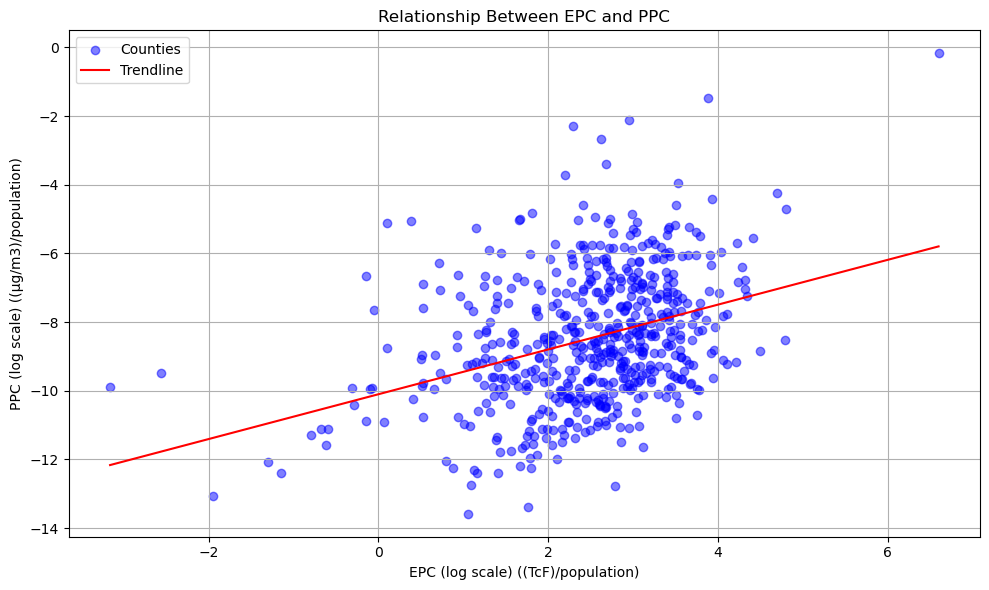

In [26]:
# Scatter plot: EPC vs. PPC
EPC = np.log(np.array(merge_df3['EPC']).astype(float))
PPC = np.log(np.array(merge_df3['PPC']).astype(float))

plt.figure(figsize=(10, 6))
plt.scatter(EPC, PPC, color='blue', alpha=0.5, label='Counties')

coefs = np.polyfit(EPC, PPC, 1)
trendline = np.poly1d(coefs)
plt.plot(EPC, trendline(EPC), color="r", label='Trendline')
plt.title('Relationship Between EPC and PPC')
plt.xlabel('EPC (log scale) ((TcF)/population)')
plt.ylabel('PPC (log scale) ((µg/m3)/population)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(scatterPlotEPCPPCPath)
plt.show()